# Time Series Traffic Forecasting


## Introduction

**What is the goal of this lab?**

In this lab you will gain experience completing data analysis and machine learning models specific to time-series data.

_This data set contains hourly traffic volume data for one of the busiest interstates in Minnesota. The goal is to predict each hour of the traffic volume for the next 4 weeks._

**Context**

Time series regression differs from regular regression because it involves data collected at specific time intervals, leading to temporal dependencies where current values are influenced by past values. This often causes autocorrelation, which violates the independent error assumption of traditional general linear regression models. Specialized techniques like ARIMA models are needed to handle trends and seasonality accurately. Ignoring these temporal structures can result in misleading inferences and poor predictions.

### Data



This lab uses the _Metro Interstate Traffic Volume_ data set about traffic on I-94 from St. Paul to Minneapolis 🚦🚙🚗.

In [ ]:
# Install package to download data sets from UCI ML Repo
!pip3 install -U ucimlrepo --quiet
from ucimlrepo import fetch_ucirepo

In [ ]:
# Get the data set
traffic = fetch_ucirepo(name="Metro Interstate Traffic Volume")

In [ ]:
# Get raw data in a pandas.DataFrame format
traffic_df = traffic.data.original

In [ ]:
# Citation
print("Citation:\n", traffic.metadata.additional_info.citation)

Citation:
 None


> _Hogue, John. (2019). Metro Interstate Traffic Volume.    
> UCI Machine Learning Repository. https://doi.org/10.24432/C5X60B._


In [ ]:
# More information
print("Check out this data set on the UCI ML Repository for more information:")
print(traffic.metadata.repository_url)

Check out this data set on the UCI ML Repository for more information:
https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume


## Problem Statement

**What are we trying to predict (include the units of the variable), what are the time intervals between predictions, and how many time periods into the future need to be predicted?**



> _We are trying to predict traffic volume, or number of vehicles passing a point per hour. Predictions are made hourly, and we are looking ahead up to 4 weeks into the future._


**How can this model be used? What decisions can be made based on the results of this model if it is accurate?**



> _If accurate, city planners can use it to decide when to adjust traffic lights, or warn commuters about busy times. It is like having a weather forecast but for traffic._


**How often should new predictions be made? Who would review the results, where would they need to see them?**



> _Predictions should be updated monthly to include the latest traffic patterns. City planners can review the results, likely through traffic management system or presentation dashboards._


**What are potential negative affects of using this model if it starts producing inaccurate results?**

> _If the model is wrong, it could mislead decisions. This could waste resources and cause more congestion and chaos._


**In quantum physics there is phenomenon called the [observer effect](https://en.wikipedia.org/wiki/Observer_effect_(physics)), where the act of observing something can change it state. Sometimes in machine learning, the act of predicting something can cause a change the resulting future values. Describe if or how that could happen here.**

> _Sometimes predicting traffic could influence it. For eg, if an app tells drivers “heavy traffic ahead,” some people might take different routes, which changes the traffic pattern._


## Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Axes: xlabel='date_time'>

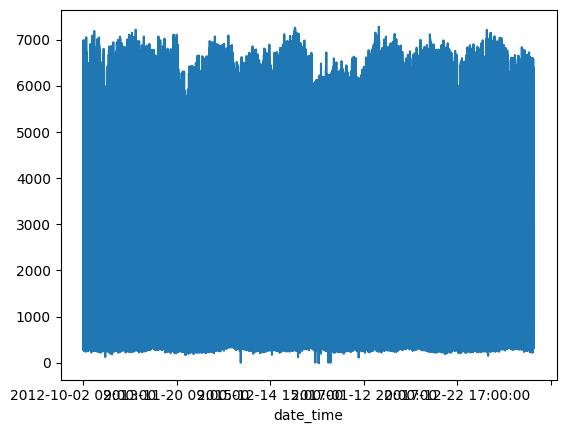

In [ ]:
traffic_df.set_index('date_time')['traffic_volume'].plot()

There is significantly amount of missing data in 2012, 2014, and 2015. For this lab we are going to filter the data set to only be after 2016.

In [ ]:
# Convert the time column to datetime format
traffic_df['date_time'] = pd.to_datetime(traffic_df['date_time'])

In [ ]:
traffic_df.groupby(traffic_df['date_time'].dt.year)['traffic_volume'].count()

,traffic_volume
date_time,
2012,2559
2013,8573
2014,4839
2015,4373
2016,9306
2017,10605
2018,7949


In [ ]:
# Filter data after Jan. 1, 2016
traffic_df = traffic_df[traffic_df['date_time'].dt.year >= 2016].copy()

### Data Inspection

Print out the following details about the data:
- The first 5 rows of the data set
- Number of rows and columns
- Data type of each column
- Number of null values (or not-null values) in each column
- General statistics of each numeric column (min, max, mean, standard deviation)

---

**Hints**

- [`pandas.DataFrame.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
- [`pandas.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)
- [`pandas.DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [ ]:
print(traffic_df.head())
print(traffic_df.info())
print(traffic_df.describe())
print(traffic_df.isnull().sum())

             holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
20344  New Years Day  265.94      0.0      0.0          90         Haze   
20345  New Years Day  265.94      0.0      0.0          90         Snow   
20346            NaN  266.00      0.0      0.0          90         Snow   
20347            NaN  266.01      0.0      0.0          90         Snow   
20348            NaN  264.80      0.0      0.0          90       Clouds   

      weather_description           date_time  traffic_volume  
20344                haze 2016-01-01 00:00:00            1513  
20345          light snow 2016-01-01 00:00:00            1513  
20346          light snow 2016-01-01 01:00:00            1550  
20347          light snow 2016-01-01 03:00:00             719  
20348     overcast clouds 2016-01-01 04:00:00             533  
<class 'pandas.core.frame.DataFrame'>
Index: 27860 entries, 20344 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
-

### Data cleaning

Time series analysis has an implicit assumption that each data point is the exact same time interval apart, but real-world data is rarely this nice.

Check to make sure that each hour timestamp appears once and there are no missing timestamps.
- If there are more than 1 records for a single timestamp, take the average all the records for that timestamp.
- If there are missing timestamps, do a linear interpolation to fill in the points that are missing.

---

**Hints**

_Identifying gaps in the data_   

Sort by the `"date_time"` column, then take the `.diff()` of that column.
Print out all the rows where the differences does not equal `pd.Timedelta(hours=1)`.
- If the difference is 0 hours then it is a duplicate timestamp.
- If the difference is greater than 1 then there are missing timestamps.


_Fixing potential gaps in the data_    

- Set the index of the data frame to be the `"date_time"` column
- Select only the `"traffic_volume"` column as a Pandas Series
- Use the [`.resample()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.resample.html) method to aggreagte duplicated records
- Use the [`.interpolate()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.interpolate.html) method to fill in missing hours with linear interpolation





In [ ]:

traffic_df = traffic_df.sort_values('date_time')


traffic_df['time_diff'] = traffic_df['date_time'].diff()

duplicate_rows = traffic_df[traffic_df['time_diff'] == pd.Timedelta(0)]
print("Duplicate timestamps:\n", duplicate_rows)

missing_rows = traffic_df[traffic_df['time_diff'] > pd.Timedelta(hours=1)]
print("Missing timestamps:\n", missing_rows)


traffic_df.set_index('date_time', inplace=True)

numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
non_numeric_cols = ['holiday', 'weather_main', 'weather_description']

traffic_numeric = traffic_df[numeric_cols].groupby(traffic_df.index).mean()
traffic_non_numeric = traffic_df[non_numeric_cols].groupby(traffic_df.index).first()

# Combine numeric & non-numeric
traffic_df_cleaned = pd.concat([traffic_numeric, traffic_non_numeric], axis=1)

traffic_df_cleaned[numeric_cols] = traffic_df_cleaned[numeric_cols].resample('h').interpolate()
traffic_df_cleaned[non_numeric_cols] = traffic_df_cleaned[non_numeric_cols].resample('h').ffill()

traffic_df_cleaned.reset_index(inplace=True)

print(traffic_df_cleaned.head(10))
print("Remaining missing values:\n", traffic_df_cleaned.isnull().sum())


Duplicate timestamps:
              holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
20345  New Years Day  265.94      0.0      0.0          90         Snow   
20400            NaN  259.25      0.0      0.0          90          Fog   
20402            NaN  258.93      0.0      0.0           1         Mist   
20404            NaN  261.23      0.0      0.0          75         Mist   
20405            NaN  261.23      0.0      0.0          75         Snow   
...              ...     ...      ...      ...         ...          ...   
48072            NaN  284.25      0.0      0.0          90      Drizzle   
48112            NaN  285.17      0.0      0.0          90      Drizzle   
48173            NaN  280.68      0.0      0.0          90       Clouds   
48193            NaN  283.48      0.0      0.0          90      Drizzle   
48195            NaN  283.84      0.0      0.0          75      Drizzle   

           weather_description           date_time  traffic_volume time_diff

### Data Visualizations and Statistics

Create 3 versions of the time series data:
- The original (no changes)
- The first difference series by 1 time period
- The difference time series by the same time of the previous day, `.diff(24)`

For each of those 3 time series preform the following tasks:
- Create a histogram plot of the values
- Create a line plot 1 weeks worth of the time series
- Create the ACF and PACF plots
- Print out the results of an Augmented Dickey-Fuller (ADF) test


---
**Hints**

_Creating the differenced time series_
- [`pandas.Series.diff()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html)

_Time series plots_
- [`statsmodels.graphics.tsaplots.plot_acf()`](https://www.statsmodels.org/dev/generated/statsmodels.graphics.tsaplots.plot_acf.html)
- [`statsmodels.graphics.tsaplots.plot_pacf()`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html)



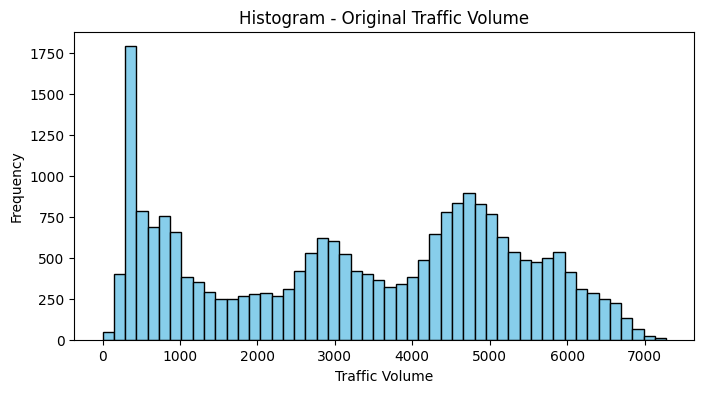

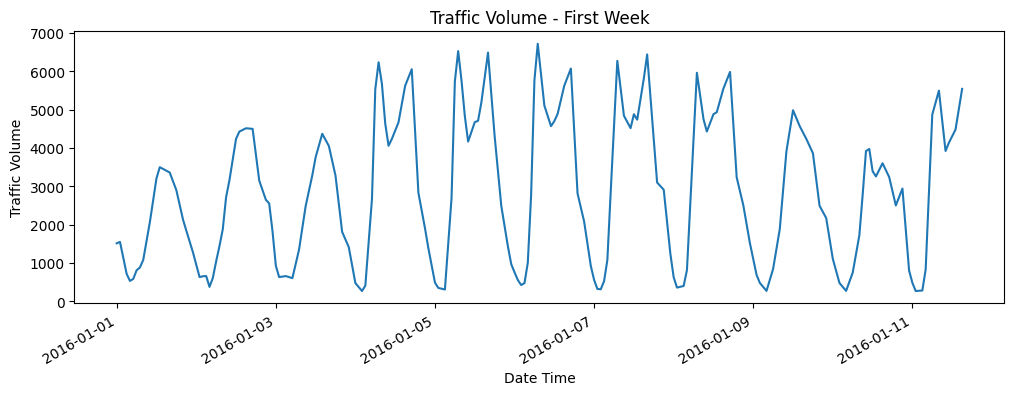

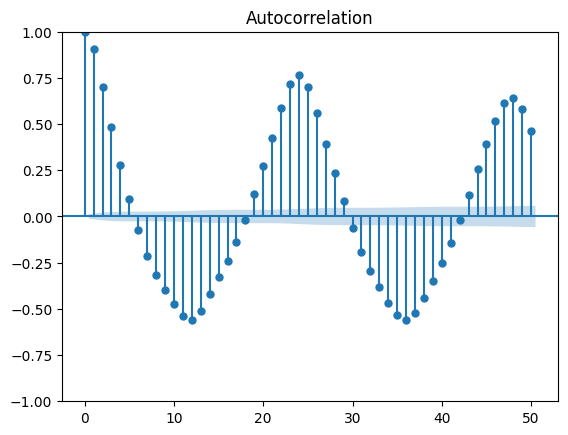

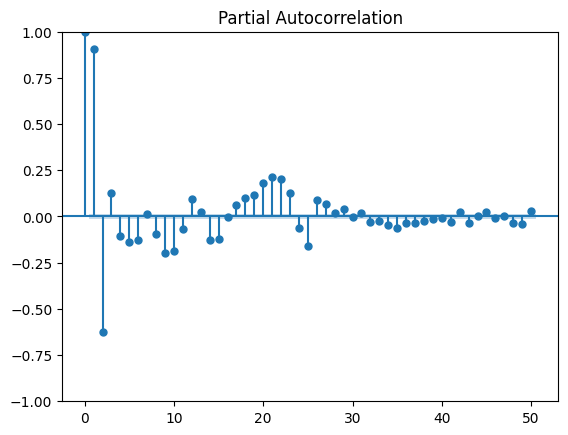

ADF Statistic (Original): -19.29328330307972
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4306339047072067), '5%': np.float64(-2.861665476813454), '10%': np.float64(-2.56683678772094)}


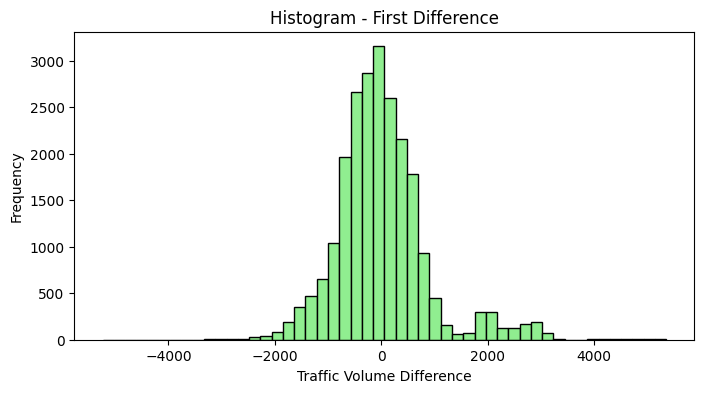

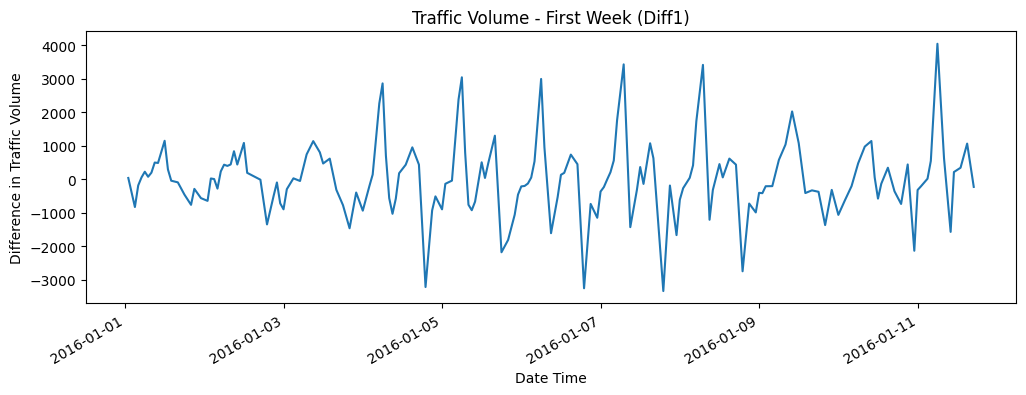

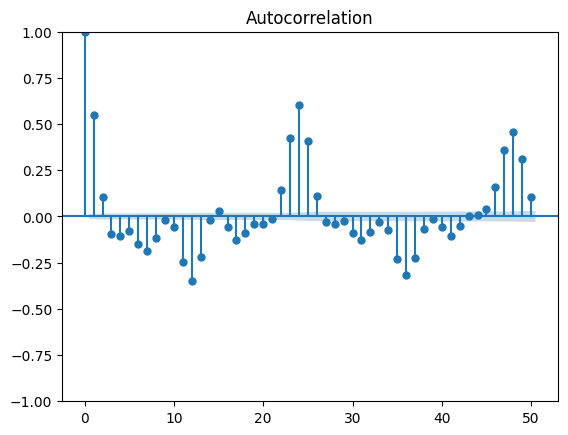

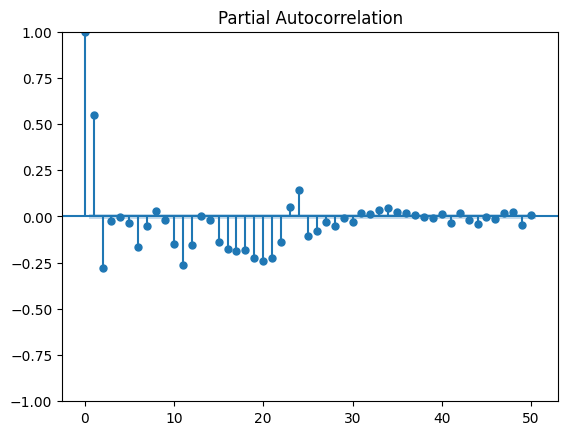

ADF Statistic (Diff1): -28.520530119706997
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4306339170335085), '5%': np.float64(-2.8616654822610252), '10%': np.float64(-2.5668367906205716)}


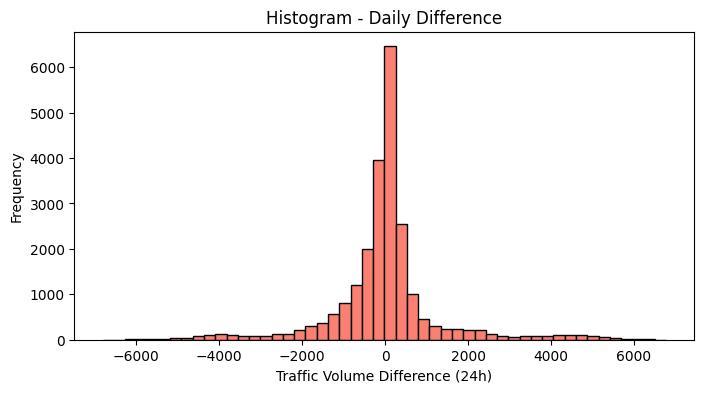

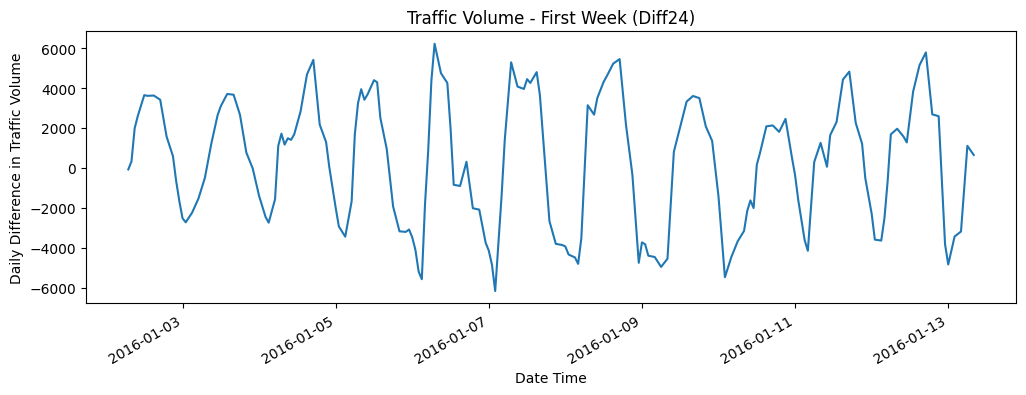

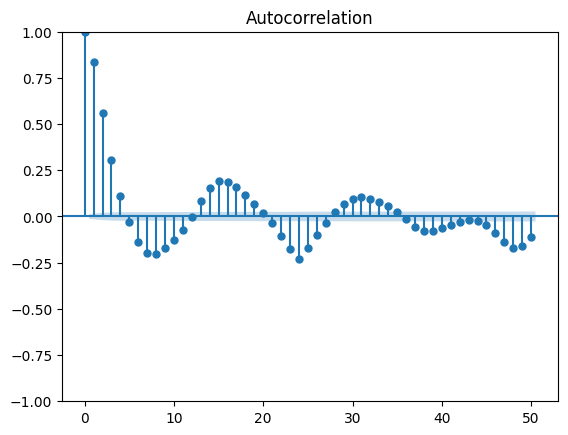

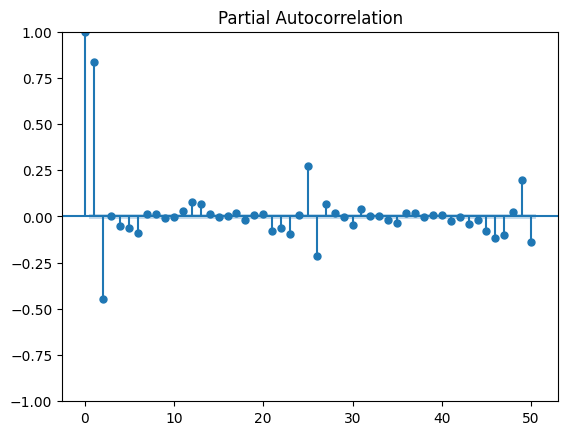

ADF Statistic (Diff24): -29.89033300197068
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430634200834152), '5%': np.float64(-2.861665607685841), '10%': np.float64(-2.5668368573816593)}


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

traffic_df_cleaned.set_index('date_time', inplace=True)
ts = traffic_df_cleaned['traffic_volume']

# 1. Original series
ts_original = ts.copy()

# Histo plot
plt.figure(figsize=(8,4))
plt.hist(ts_original, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram - Original Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

# 1-week line plot
plt.figure(figsize=(12,4))
ts_original[:24*7].plot()
plt.title("Traffic Volume - First Week")
plt.xlabel("Date Time")
plt.ylabel("Traffic Volume")
plt.show()

# ACF & PACF
plot_acf(ts_original, lags=50)
plt.show()
plot_pacf(ts_original, lags=50)
plt.show()

# ADF test
adf_result = adfuller(ts_original)
print("ADF Statistic (Original):", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])


### 2. First difference (lag 1)
ts_diff1 = ts_original.diff().dropna()

# Hist plot
plt.figure(figsize=(8,4))
plt.hist(ts_diff1, bins=50, color='lightgreen', edgecolor='black')
plt.title("Histogram - First Difference")
plt.xlabel("Traffic Volume Difference")
plt.ylabel("Frequency")
plt.show()

# 1 week plot
plt.figure(figsize=(12,4))
ts_diff1[:24*7].plot()
plt.title("Traffic Volume - First Week (Diff1)")
plt.xlabel("Date Time")
plt.ylabel("Difference in Traffic Volume")
plt.show()

# ACF & PACF
plot_acf(ts_diff1, lags=50)
plt.show()
plot_pacf(ts_diff1, lags=50)
plt.show()

# ADF
adf_result_diff1 = adfuller(ts_diff1)
print("ADF Statistic (Diff1):", adf_result_diff1[0])
print("p-value:", adf_result_diff1[1])
print("Critical Values:", adf_result_diff1[4])


### 3. Daily difference (lag 24)
ts_diff24 = ts_original.diff(24).dropna()

# Hist plot
plt.figure(figsize=(8,4))
plt.hist(ts_diff24, bins=50, color='salmon', edgecolor='black')
plt.title("Histogram - Daily Difference")
plt.xlabel("Traffic Volume Difference (24h)")
plt.ylabel("Frequency")
plt.show()

# 1-week line
plt.figure(figsize=(12,4))
ts_diff24[:24*7].plot()
plt.title("Traffic Volume - First Week (Diff24)")
plt.xlabel("Date Time")
plt.ylabel("Daily Difference in Traffic Volume")
plt.show()

# ACF & PACF
plot_acf(ts_diff24, lags=50)
plt.show()
plot_pacf(ts_diff24, lags=50)
plt.show()

# ADF
adf_result_diff24 = adfuller(ts_diff24)
print("ADF Statistic (Diff24):", adf_result_diff24[0])
print("p-value:", adf_result_diff24[1])
print("Critical Values:", adf_result_diff24[4])


## Models

A SARIMA (Seasonal Autoregressive Integrated Moving Average) model is an extension of the ARIMA model that incorporates seasonality.

**Key Components of SARIMA**

- **Autoregressive (AR) terms**: Represented by $ p $, these terms account for the relationship between an observation and a number of lagged observations.
- **Integrated (I) terms**: Represented by $ d $, these terms indicate the number of differencing operations needed to make the time series stationary.
- **Moving Average (MA) terms**: Represented by $ q $, these terms model the relationship between an observation and a residual error from a moving average model applied to lagged observations.

**Seasonal Components**

- **Seasonal Autoregressive (SAR) terms**: Represented by $ P $, these terms account for the seasonal autoregression.
- **Seasonal Integrated (SI) terms**: Represented by $ D $, these terms indicate the number of seasonal differencing operations.
- **Seasonal Moving Average (SMA) terms**: Represented by $ Q $, these terms account for the seasonal moving average.
- **Seasonal Period (S)**: This represents the number of time steps for a single seasonal period (e.g., 12 for monthly data with yearly seasonality).

**Notation**

A SARIMA model is usually denoted as:

$$ SARIMA(p, d, q) \times (P, D, Q)_S $$

_Where:_
- $ p $: Non-seasonal autoregressive order
- $ d $: Non-seasonal differencing order
- $ q $: Non-seasonal moving average order
- $ P $: Seasonal autoregressive order
- $ D $: Seasonal differencing order
- $ Q $: Seasonal moving average order
- $ S $: Length of the seasonal cycle

_Example_

$$ SARIMA(1, 1, 1) \times (1, 1, 1)_{12} $$

---

Split the time-series data into a train and test set. The test set should be that last 4 weeks of data.

Train SARIMA models with the following configurations:

- $SARIMA(0, 1, 1) \times (0, 0, 0)_{0}$
- $SARIMA(1, 1, 0) \times (0, 0, 0)_{0}$
- $SARIMA(1, 1, 1) \times (0, 0, 0)_{0}$
- $SARIMA(0, 0, 0) \times (0, 1, 1)_{24}$
- $SARIMA(0, 0, 0) \times (1, 1, 0)_{24}$
- $SARIMA(0, 0, 0) \times (1, 1, 1)_{24}$
- $SARIMA(1, 0, 1) \times (1, 1, 1)_{24}$

Also chose 3 other configurations with hyper parameters that you chose.

For each of the trained models:
 - Print out the model summary
 - Print out the RMSE on the testing data set
 - Plot the last 2 weeks of training data with the testing data set and the predictions to visualize how close the prediction are to the actual values.


> _❗**NOTE:** it is possible that you will hit the maximum RAM for the free version of Google Colab or the runtime of the model is very long (10+ minutes). If this happens there are 2 things you should try to help:_
- _Set the `maxiter` parameter of the `.fit()` method of `SARIMAX`. To limit the runtime._
- _You can filter out some of the training data to only use the most recent 1 or 2 years of data to improve memory and runtime._


---
**Hints**
 - [`statsmodels.tsa.statespace.sarimax.SARIMAX`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
 - [`sklearn.metrics.root_mean_squared_error()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt



Training SARIMA(0, 1, 1)x((0, 0, 0),0)...


/tmp/ipython-input-1710166523.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  traffic_recent = traffic_df_cleaned.last('2Y')
/tmp/ipython-input-1710166523.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  traffic_recent = traffic_df_cleaned.last('2Y')
/tmp/ipython-input-1710166523.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  traffic_recent = traffic_recent.asfreq('H')


RMSE: 2911
                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                14640
Model:               SARIMAX(0, 1, 1)   Log Likelihood             -115070.034
Date:                Sat, 29 Nov 2025   AIC                         230144.069
Time:                        05:57:58   BIC                         230159.251
Sample:                    01-01-2017   HQIC                        230149.112
                         - 09-02-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6398      0.005    130.979      0.000       0.630       0.649
sigma2      4.295e+05   3582.973    119.873      0.000    4.22e+05    4.37e+05
Ljung-Box (L1) (Q):                 400.5

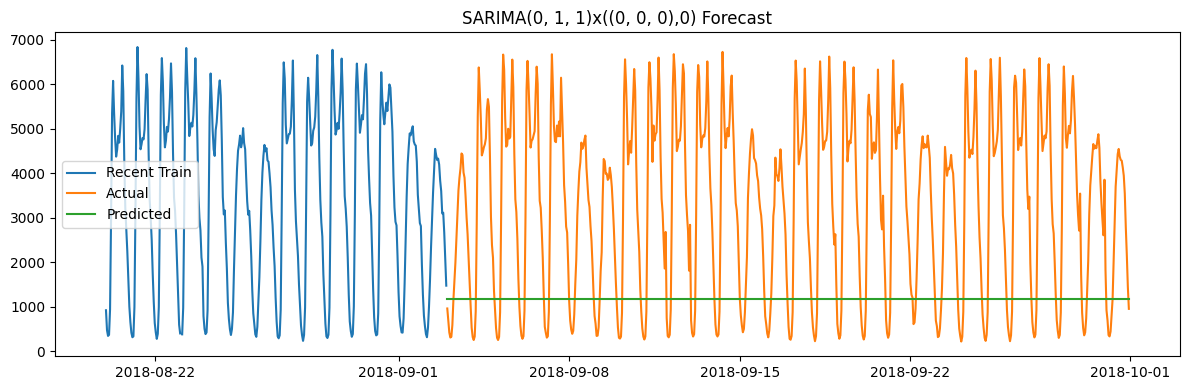


Training SARIMA(1, 1, 0)x((0, 0, 0),0)...
RMSE: 3362
                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                14640
Model:               SARIMAX(1, 1, 0)   Log Likelihood             -115351.843
Date:                Sat, 29 Nov 2025   AIC                         230707.686
Time:                        05:57:58   BIC                         230722.869
Sample:                    01-01-2017   HQIC                        230712.729
                         - 09-02-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5986      0.005    132.128      0.000       0.590       0.608
sigma2      4.393e+05   3729.233    117.801      0.000    4.32e+05    4.47e+0

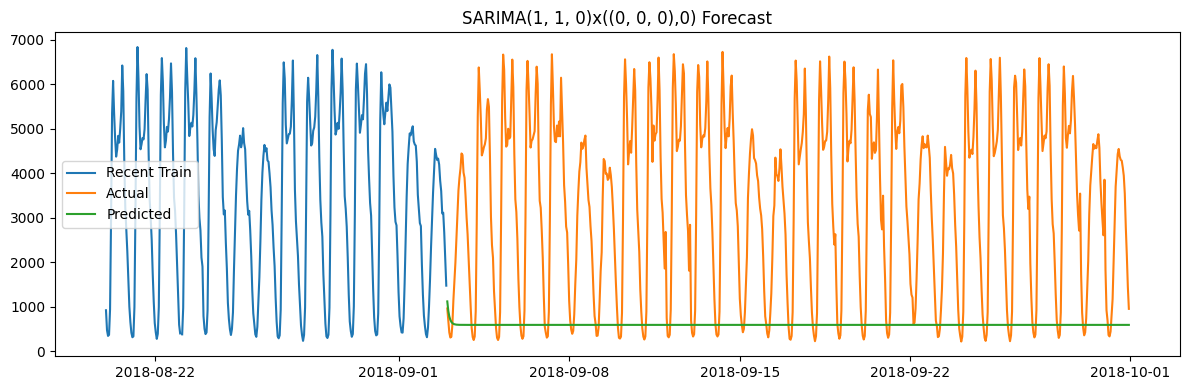


Training SARIMA(1, 1, 1)x((0, 0, 0),0)...
RMSE: 3092
                               SARIMAX Results                                
Dep. Variable:         traffic_volume   No. Observations:                14640
Model:               SARIMAX(1, 1, 1)   Log Likelihood             -114579.446
Date:                Sat, 29 Nov 2025   AIC                         229164.891
Time:                        05:58:00   BIC                         229187.665
Sample:                    01-01-2017   HQIC                        229172.456
                         - 09-02-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3646      0.010     37.428      0.000       0.346       0.384
ma.L1          0.4325      0.010     42.554      0.000       0.413       0.45

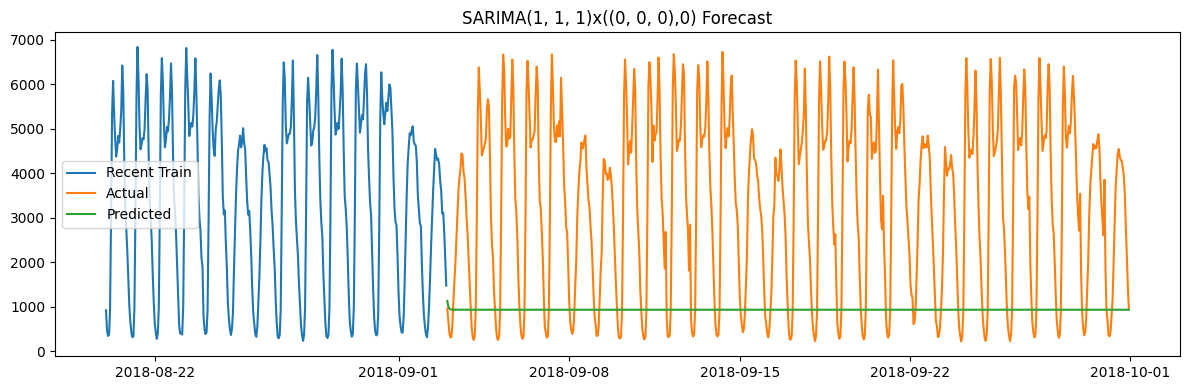


Training SARIMA(0, 0, 0)x((0, 1, 1),24)...
RMSE: 878
                                 SARIMAX Results                                  
Dep. Variable:             traffic_volume   No. Observations:                14640
Model:             SARIMAX(0, 1, [1], 24)   Log Likelihood             -119617.099
Date:                    Sat, 29 Nov 2025   AIC                         239238.198
Time:                            05:59:11   BIC                         239253.374
Sample:                        01-01-2017   HQIC                        239243.240
                             - 09-02-2018                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L24      -0.9993      0.004   -268.626      0.000      -1.007      -0.992
sigma2      8.192e+05   5989.546    136.769  

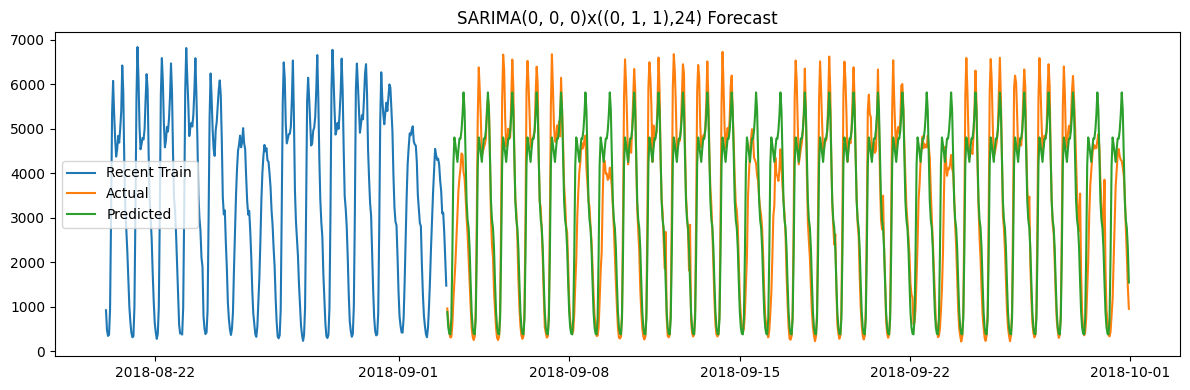


Training SARIMA(0, 0, 0)x((1, 1, 0),24)...
RMSE: 1558
                                SARIMAX Results                                 
Dep. Variable:           traffic_volume   No. Observations:                14640
Model:             SARIMAX(1, 1, 0, 24)   Log Likelihood             -121260.700
Date:                  Sat, 29 Nov 2025   AIC                         242525.401
Time:                          05:59:24   BIC                         242540.577
Sample:                      01-01-2017   HQIC                        242530.443
                           - 09-02-2018                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.0412      0.010     -4.258      0.000      -0.060      -0.022
sigma2      1.042e+06   5557.739    187.507      0.000    1.

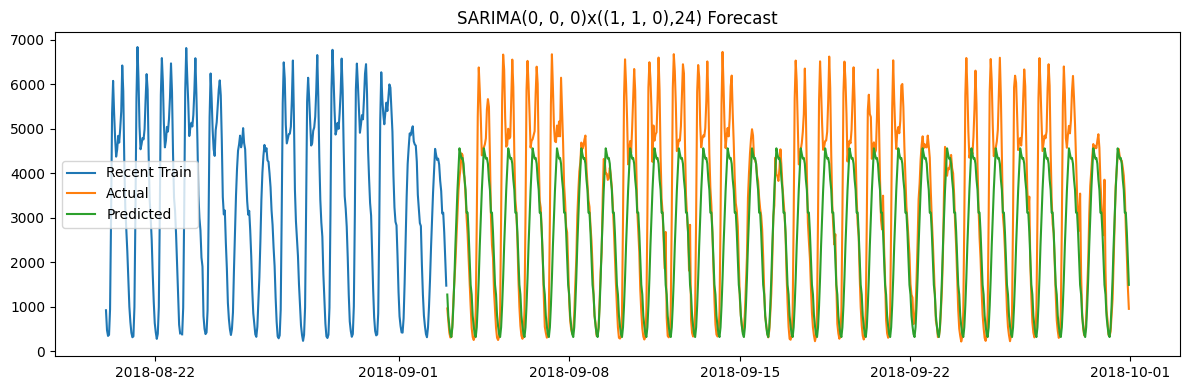


Training SARIMA(0, 0, 0)x((1, 1, 1),24)...
RMSE: 863
                                 SARIMAX Results                                  
Dep. Variable:             traffic_volume   No. Observations:                14640
Model:             SARIMAX(1, 1, [1], 24)   Log Likelihood             -118547.887
Date:                    Sat, 29 Nov 2025   AIC                         237101.775
Time:                            06:01:35   BIC                         237124.539
Sample:                        01-01-2017   HQIC                        237109.338
                             - 09-02-2018                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24       0.3700      0.004     88.055      0.000       0.362       0.378
ma.S.L24      -1.0000      0.163     -6.117  

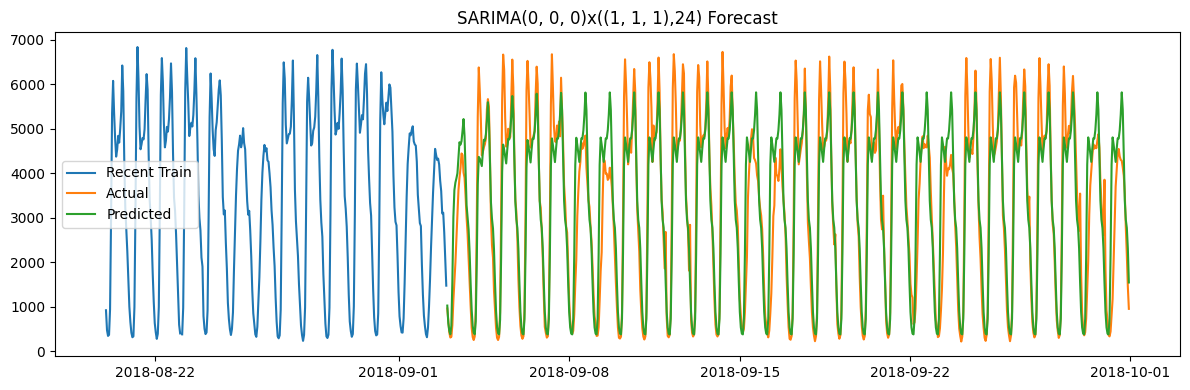


Training SARIMA(1, 0, 1)x((1, 1, 1),24)...
RMSE: 864
                                     SARIMAX Results                                      
Dep. Variable:                     traffic_volume   No. Observations:                14640
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood             -107526.098
Date:                            Sat, 29 Nov 2025   AIC                         215062.196
Time:                                    06:05:00   BIC                         215100.136
Sample:                                01-01-2017   HQIC                        215074.801
                                     - 09-02-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7719      0.005    142.596      0.000      

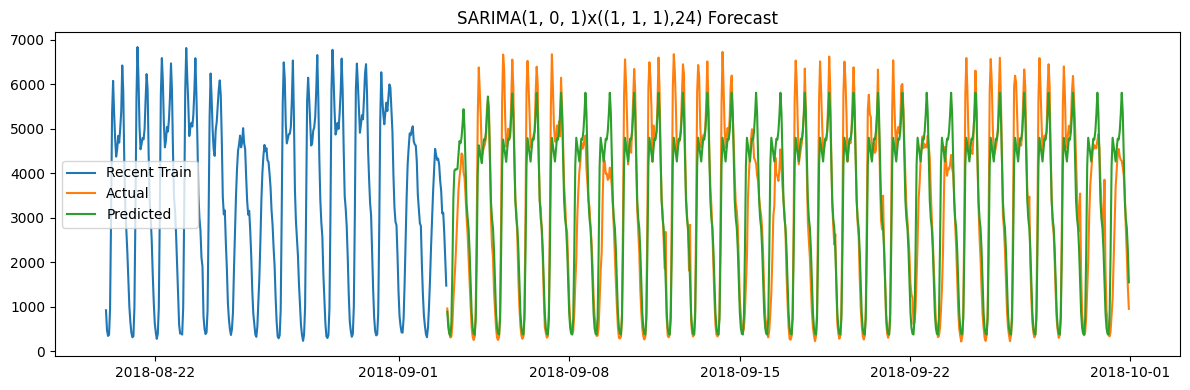


Training SARIMA(2, 1, 0)x((0, 1, 1),24)...
RMSE: 876
                                      SARIMAX Results                                       
Dep. Variable:                       traffic_volume   No. Observations:                14640
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 24)   Log Likelihood             -108511.323
Date:                              Sat, 29 Nov 2025   AIC                         217030.645
Time:                                      06:07:23   BIC                         217060.997
Sample:                                  01-01-2017   HQIC                        217040.729
                                       - 09-02-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4611      0.005     94.451 

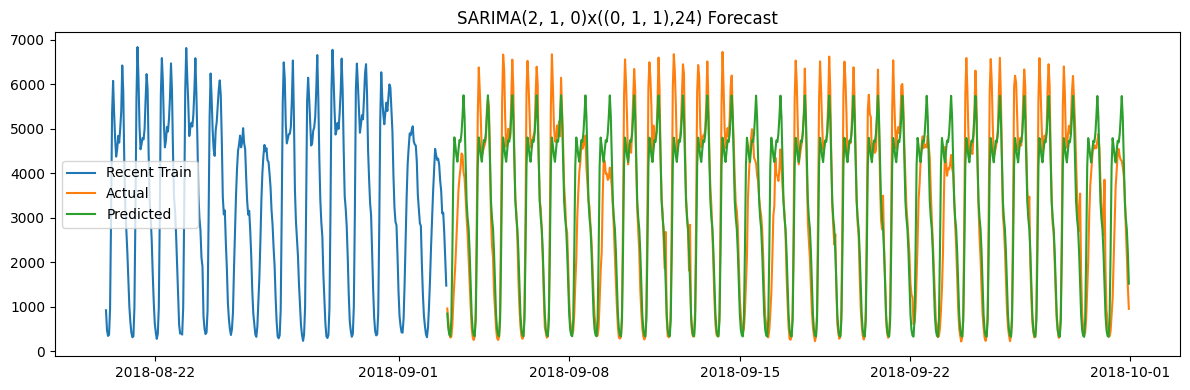


Training SARIMA(0, 1, 2)x((1, 0, 1),24)...
RMSE: 877
                                      SARIMAX Results                                       
Dep. Variable:                       traffic_volume   No. Observations:                14640
Model:             SARIMAX(0, 1, 2)x(1, 0, [1], 24)   Log Likelihood             -110492.009
Date:                              Sat, 29 Nov 2025   AIC                         220994.017
Time:                                      06:08:25   BIC                         221031.965
Sample:                                  01-01-2017   HQIC                        221006.624
                                       - 09-02-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4609      0.011     40.134 

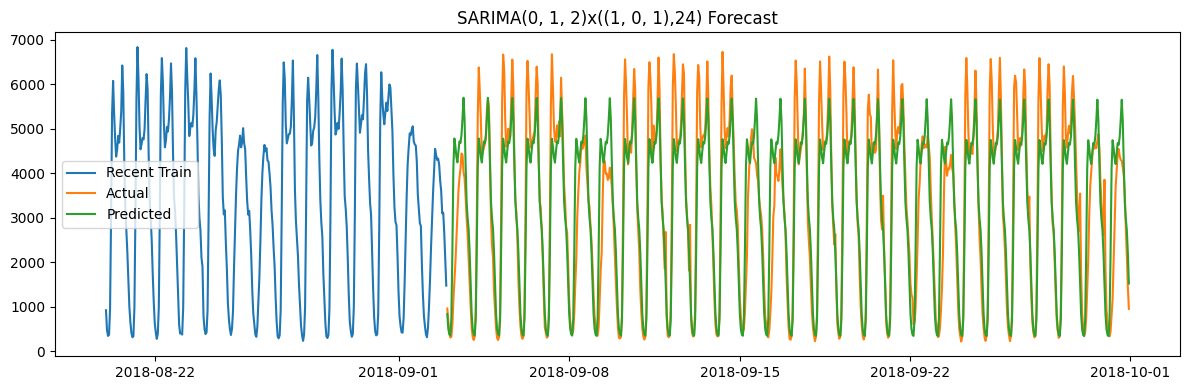


Training SARIMA(1, 1, 1)x((1, 1, 0),24)...
RMSE: 5347
                                      SARIMAX Results                                      
Dep. Variable:                      traffic_volume   No. Observations:                14640
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 24)   Log Likelihood             -111302.251
Date:                             Sat, 29 Nov 2025   AIC                         222612.503
Time:                                     06:09:11   BIC                         222642.855
Sample:                                 01-01-2017   HQIC                        222622.587
                                      - 09-02-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1023      0.016      6.369      0.

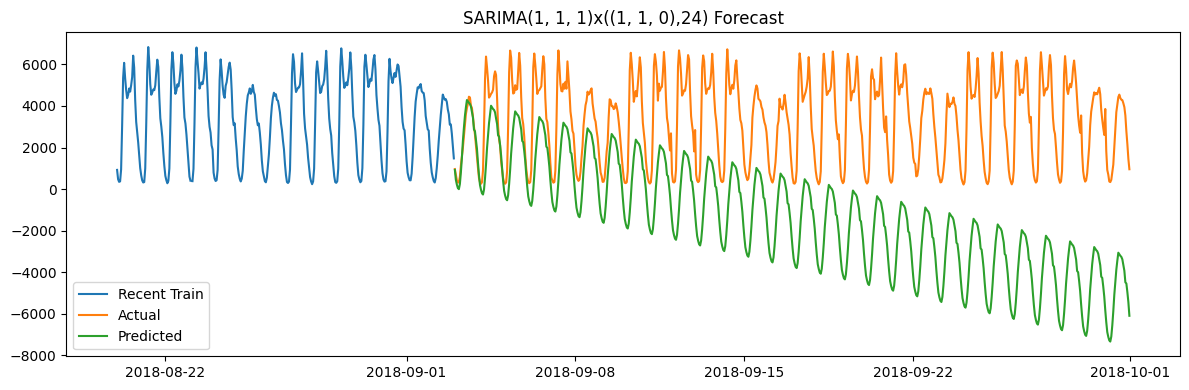


RMSE comparison:
                                       RMSE
SARIMA(0, 0, 0)x((1, 1, 1),24)   862.882894
SARIMA(1, 0, 1)x((1, 1, 1),24)   864.474480
SARIMA(2, 1, 0)x((0, 1, 1),24)   875.684010
SARIMA(0, 1, 2)x((1, 0, 1),24)   876.517817
SARIMA(0, 0, 0)x((0, 1, 1),24)   878.121900
SARIMA(0, 0, 0)x((1, 1, 0),24)  1558.007312
SARIMA(0, 1, 1)x((0, 0, 0),0)   2911.089663
SARIMA(1, 1, 1)x((0, 0, 0),0)   3091.690099
SARIMA(1, 1, 0)x((0, 0, 0),0)   3362.054500
SARIMA(1, 1, 1)x((1, 1, 0),24)  5346.557320


In [ ]:
traffic_recent = traffic_df_cleaned.last('2Y')

traffic_recent = traffic_recent.asfreq('H')
ts = traffic_recent['traffic_volume']

# Split train/test: last 4 weeks as test
test_hours = 28*24
train, test = ts[:-test_hours], ts[-test_hours:]

# SARIMA configs:
models_to_try = [
    (0,1,1,0,0,0,0),
    (1,1,0,0,0,0,0),
    (1,1,1,0,0,0,0),
    (0,0,0,0,1,1,24),
    (0,0,0,1,1,0,24),
    (0,0,0,1,1,1,24),
    (1,0,1,1,1,1,24),
    # 3 extra of my choice
    (2,1,0,0,1,1,24),
    (0,1,2,1,0,1,24),
    (1,1,1,1,1,0,24)
]

rmse_results = {}

for p,d,q,P,D,Q,s in models_to_try:
    print(f"\nTraining SARIMA{(p,d,q)}x({P,D,Q},{s})...")
    try:
        model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,s),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(maxiter=50, disp=False)
        forecast = model_fit.forecast(steps=len(test))

        rmse = sqrt(mean_squared_error(test, forecast))
        rmse_results[f"SARIMA{(p,d,q)}x({P,D,Q},{s})"] = rmse
        print(f"RMSE: {rmse:.0f}")

        print(model_fit.summary())

        # Plot last 2 weeks of training + testing vs prediction
        plt.figure(figsize=(12,4))
        plt.plot(train[-24*14:], label='Recent Train', linewidth=1.5)
        plt.plot(test, label='Actual', linewidth=1.5)
        plt.plot(forecast, label='Predicted', linewidth=1.5)
        plt.title(f"SARIMA{(p,d,q)}x({P,D,Q},{s}) Forecast", fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("This model failed:", e)

# Compare RMSE
rmse_df = pd.DataFrame.from_dict(rmse_results, orient='index', columns=['RMSE']).sort_values('RMSE')
print("\nRMSE comparison:")
print(rmse_df)

## Conclusion

**What is the Augmented Dickey-Fuller (ADF) test? Describe what it is used for and why it is needed.**

> _The (ADF) test checks if a time series is stationary, meaning its statistical properties like mean and variance do not change over time. It is needed because of SARIMA models require stationary data for reliable forecasting/predictions._

**Describe in detail what are ACF and PACF plots, why you should use them, and how they should be interpreted.**


> _ACF and PACF plots show how current values relate to past values. ACF measures overall correlation with lagged values, and PACF isolates direct correlations at each lag.

**What parameters $ (p, d, q) \times (P, D, Q)_S $ would you expect to work well in the SARIMA model based on the graphs and statistical tests in the EDA? Describe your reasoning in detail.**

> _Based on the EDA and plots, I would expect models with low-order differencing (d=1), a small AR or MA component, and seasonal terms (D=1, Q=1) with S=24 for daily patterns to perform well. This captures both short trends and daily trends._

**Which SARIMA model hyperparameters worked the best and based on what can you make that determination? Does that match what you would expect from the EDA?**

> _The SARIMA(1,0,1)x(1,1,1,24) model worked best, determined by its lowest RMSE on the data set. This matches from the EDA because it accounts for both non seasonal and seasonal trends observed in the data._

**What would you try next to continue improving the model?**

> _To improve the model further, I would try including additional seasonal cycles, tuning hyperparameters more, and adding external factors such as holidays that might influence traffic volume_